In [17]:
from pathlib import Path
import pandas as pd
import numpy as np

print(Path.cwd())

raw_data_dir = Path("../data/raw")
csv_files = sorted(raw_data_dir.glob("*.csv"))

print(f"\nCSV files found: {len(csv_files)}")

for file in csv_files:
    print("-", file.name)
    

c:\Users\DELL\Documents\Github\ecommerce-delivery-reliability-analysis\notebooks

CSV files found: 9
- olist_customers_dataset.csv
- olist_geolocation_dataset.csv
- olist_order_items_dataset.csv
- olist_order_payments_dataset.csv
- olist_order_reviews_dataset.csv
- olist_orders_dataset.csv
- olist_products_dataset.csv
- olist_sellers_dataset.csv
- product_category_name_translation.csv


# Data inventory

This notebook identifies the raw tables in the Olist e-commerce dataset and
examines their structure before they are combined for analysis.

The data is stored in several related CSV files rather than one spreadsheet.
Understanding each table and its columns is the first step before creating
reliable joins.


In [18]:
table_inventory = []

for file in csv_files:
    sample = pd.read_csv(file, nrows=5)

    table_inventory.append(
        {
            "file_name": file.name,
            "column_count": sample.shape[1],
            "columns": ", ".join(sample.columns)
        }
    )

table_inventory = pd.DataFrame(table_inventory)

table_inventory

,file_name,column_count,columns
0,olist_customers_dataset.csv,5,"customer_id, customer_unique_id, customer_zip_..."
1,olist_geolocation_dataset.csv,5,"geolocation_zip_code_prefix, geolocation_lat, ..."
2,olist_order_items_dataset.csv,7,"order_id, order_item_id, product_id, seller_id..."
3,olist_order_payments_dataset.csv,5,"order_id, payment_sequential, payment_type, pa..."
4,olist_order_reviews_dataset.csv,7,"review_id, order_id, review_score, review_comm..."
5,olist_orders_dataset.csv,8,"order_id, customer_id, order_status, order_pur..."
6,olist_products_dataset.csv,9,"product_id, product_category_name, product_nam..."
7,olist_sellers_dataset.csv,4,"seller_id, seller_zip_code_prefix, seller_city..."
8,product_category_name_translation.csv,2,"product_category_name, product_category_name_e..."


## Core table: orders

The orders table is the central table in this project. It records each order's
status, purchase time, estimated delivery date, and actual delivery date.

Other tables will be connected to this table using `order_id`.


In [19]:
orders = pd.read_csv(raw_data_dir / "olist_orders_dataset.csv")

print(f"Orders table shape: {orders.shape}")
print("\nColumn names:")
print(orders.columns.tolist())

orders.head()

Orders table shape: (99441, 8)

Column names:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [20]:
print(f"Total orders: {len(orders):,}")
print(f"Duplicate order IDs: {orders['order_id'].duplicated().sum()}")

order_status_summary = (
    orders["order_status"]
    .value_counts()
    .rename_axis("order_status")
    .reset_index(name="order_count")
)

order_status_summary

Total orders: 99,441
Duplicate order IDs: 0


,order_status,order_count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


## Delivered-order data quality

Delivery reliability can only be measured for delivered orders because these
records have an actual customer delivery date. Before calculating delays, the
required date fields must be checked for missing values.

In [21]:
delivered_orders = orders.loc[
    orders["order_status"].eq("delivered")
].copy()

required_date_columns = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

delivery_date_audit = pd.DataFrame(
    {
        "missing_values": delivered_orders[required_date_columns].isna().sum(),
        "missing_percentage": (
            delivered_orders[required_date_columns].isna().mean() * 100
        ).round(2)
    }
)

delivery_date_audit

,missing_values,missing_percentage
order_purchase_timestamp,0,0.00
order_delivered_customer_date,8,0.01
order_estimated_delivery_date,0,0.00


### Decision

Eight delivered orders have no recorded customer-delivery date. They cannot be
used to calculate delivery delay, so they will be excluded only from
delivery-time calculations.

In [22]:
analysis_orders = delivered_orders.dropna(
    subset=["order_delivered_customer_date"]
).copy()

for column in required_date_columns:
    analysis_orders[column] = pd.to_datetime(analysis_orders[column])

analysis_orders["delivery_days"] = (
    analysis_orders["order_delivered_customer_date"]
    - analysis_orders["order_purchase_timestamp"]
).dt.total_seconds() / 86_400

analysis_orders["delivery_gap_days"] = (
    analysis_orders["order_delivered_customer_date"]
    - analysis_orders["order_estimated_delivery_date"]
).dt.total_seconds() / 86_400

analysis_orders["late_delivery"] = analysis_orders[
    "delivery_gap_days"
].gt(0)

analysis_orders[
    [
        "order_id",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "delivery_days",
        "delivery_gap_days",
        "late_delivery"
    ]
].head()

,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_gap_days,late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,8.436574,-7.107488,False
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,13.782037,-5.355729,False
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,9.394213,-17.245498,False
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,13.208750,-12.980069,False
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,2.873877,-9.238171,False


In [23]:
late_delivery_count = analysis_orders["late_delivery"].sum()
total_delivery_records = len(analysis_orders)

delivery_baseline = pd.DataFrame(
    {
        "metric": [
            "Delivered orders analysed",
            "Late deliveries",
            "Late-delivery rate (%)",
            "Median delivery time (days)",
            "Mean delivery time (days)",
            "Median delivery gap (days)"
        ],
        "value": [
            total_delivery_records,
            late_delivery_count,
            round(100 * late_delivery_count / total_delivery_records, 2),
            round(analysis_orders["delivery_days"].median(), 2),
            round(analysis_orders["delivery_days"].mean(), 2),
            round(analysis_orders["delivery_gap_days"].median(), 2)
        ]
    }
)

delivery_baseline

,metric,value
0,Delivered orders analysed,96470.00
1,Late deliveries,7826.00
2,Late-delivery rate (%),8.11
3,Median delivery time (days),10.22
4,Mean delivery time (days),12.56
5,Median delivery gap (days),-11.95


## Initial delivery baseline

Among 96,470 delivered orders with a recorded customer-delivery date, 8.11%
arrived after the estimated delivery date.

The median delivery time was 10.22 days. The median delivery gap was −11.95
days, meaning that the typical delivered order arrived before its estimated
delivery date. This result describes the historical Olist dataset and may
reflect conservative delivery estimates.

## Order items: a one-to-many relationship

The orders table has one row per order. The order-items table has one row per
item within an order, so a single order can appear multiple times.

This distinction is important: joining tables without understanding it can
accidentally duplicate orders and produce incorrect results.

In [24]:
order_items = pd.read_csv(
    raw_data_dir / "olist_order_items_dataset.csv"
)

items_per_order = order_items.groupby("order_id").size()

print(f"Order-item rows: {len(order_items):,}")
print(f"Unique orders in order-items table: {order_items['order_id'].nunique():,}")
print(f"Median items per order: {items_per_order.median():.0f}")
print(f"Maximum items in one order: {items_per_order.max():.0f}")

order_items.head()

Order-item rows: 112,650
Unique orders in order-items table: 98,666
Median items per order: 1
Maximum items in one order: 21


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


### Creating an order-level item summary

Before joining order items to the orders table, item-level rows are aggregated
to one row per `order_id`. This preserves the correct unit of analysis: one row
per order.

In [25]:
order_item_summary = (
    order_items
    .groupby("order_id")
    .agg(
        item_count=("order_item_id", "size"),
        unique_products=("product_id", "nunique"),
        unique_sellers=("seller_id", "nunique"),
        total_item_value=("price", "sum"),
        total_freight_value=("freight_value", "sum")
    )
    .reset_index()
)

print(f"Rows in order-level item summary: {len(order_item_summary):,}")
print(f"Duplicate order IDs: {order_item_summary['order_id'].duplicated().sum()}")

order_item_summary.head()

Rows in order-level item summary: 98,666
Duplicate order IDs: 0


,order_id,item_count,unique_products,unique_sellers,total_item_value,total_freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,1,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,1,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1,199.90,18.14


In [26]:
delivery_orders = analysis_orders.merge(
    order_item_summary,
    on="order_id",
    how="left",
    validate="one_to_one"
)

delivery_orders["total_order_value"] = (
    delivery_orders["total_item_value"]
    + delivery_orders["total_freight_value"]
)

print(f"Rows after join: {len(delivery_orders):,}")
print(f"Duplicate order IDs after join: {delivery_orders['order_id'].duplicated().sum()}")
print(f"Orders missing item information: {delivery_orders['item_count'].isna().sum()}")

delivery_orders[
    [
        "order_id",
        "late_delivery",
        "item_count",
        "unique_sellers",
        "total_item_value",
        "total_freight_value",
        "total_order_value"
    ]
].head()

Rows after join: 96,470
Duplicate order IDs after join: 0
Orders missing item information: 0


,order_id,late_delivery,item_count,unique_sellers,total_item_value,total_freight_value,total_order_value
0,e481f51cbdc54678b7cc49136f2d6af7,False,1,1,29.99,8.72,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,False,1,1,118.70,22.76,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,False,1,1,159.90,19.22,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,False,1,1,45.00,27.20,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,False,1,1,19.90,8.72,28.62


## Customer information

The customers table connects to orders through `customer_id`.

`customer_id` identifies a customer record associated with an order, while
`customer_unique_id` identifies the same person across possible repeat orders.
For delivery analysis, customer state will help compare delivery reliability
across destinations.

In [27]:
customers = pd.read_csv(
    raw_data_dir / "olist_customers_dataset.csv"
)

print(f"Customer rows: {len(customers):,}")
print(f"Duplicate customer IDs: {customers['customer_id'].duplicated().sum()}")
print(f"Unique customer people: {customers['customer_unique_id'].nunique():,}")

customers.head()

Customer rows: 99,441
Duplicate customer IDs: 0
Unique customer people: 96,096


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [28]:
customer_lookup = customers[
    [
        "customer_id",
        "customer_unique_id",
        "customer_city",
        "customer_state"
    ]
].rename(
    columns={
        "customer_city": "customer_city",
        "customer_state": "customer_state"
    }
)

delivery_orders = delivery_orders.merge(
    customer_lookup,
    on="customer_id",
    how="left",
    validate="one_to_one"
)

print(f"Rows after customer join: {len(delivery_orders):,}")
print(f"Orders missing customer state: {delivery_orders['customer_state'].isna().sum()}")

delivery_orders[
    [
        "order_id",
        "customer_unique_id",
        "customer_city",
        "customer_state",
        "late_delivery",
        "delivery_days"
    ]
].head()

Rows after customer join: 96,470
Orders missing customer state: 0


,order_id,customer_unique_id,customer_city,customer_state,late_delivery,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,False,8.436574
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,barreiras,BA,False,13.782037
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,False,9.394213
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,False,13.208750
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,False,2.873877


## Delivery reliability by customer state

Customer state is used as a destination-level comparison. This analysis identifies
where late-delivery rates differed in this historical dataset; it does not prove
that location alone caused late delivery.

In [29]:
state_delivery_summary = (
    delivery_orders
    .groupby("customer_state")
    .agg(
        order_count=("order_id", "size"),
        late_delivery_count=("late_delivery", "sum"),
        late_delivery_rate=("late_delivery", "mean"),
        median_delivery_days=("delivery_days", "median"),
        median_delivery_gap_days=("delivery_gap_days", "median")
    )
    .reset_index()
)

state_delivery_summary["late_delivery_rate_pct"] = (
    state_delivery_summary["late_delivery_rate"] * 100
).round(2)

state_delivery_summary["median_delivery_days"] = (
    state_delivery_summary["median_delivery_days"].round(2)
)

state_delivery_summary["median_delivery_gap_days"] = (
    state_delivery_summary["median_delivery_gap_days"].round(2)
)

state_delivery_summary = state_delivery_summary.sort_values(
    ["late_delivery_rate_pct", "order_count"],
    ascending=[False, False]
)

state_delivery_summary.head(10)

,customer_state,order_count,late_delivery_count,late_delivery_rate,median_delivery_days,median_delivery_gap_days,late_delivery_rate_pct
1,AL,397,95,0.239295,22.33,-9.43,23.93
9,MA,717,141,0.196653,19.19,-10.01,19.67
16,PI,476,76,0.159664,16.29,-13.08,15.97
5,CE,1279,196,0.153245,18.21,-12.27,15.32
24,SE,335,51,0.152239,18.01,-12.13,15.22
4,BA,3256,457,0.140356,16.91,-11.56,14.04
18,RJ,12350,1664,0.134737,12.04,-12.26,13.47
26,TO,274,35,0.127737,15.87,-12.62,12.77
13,PA,946,117,0.123679,21.08,-15.08,12.37
7,ES,1995,244,0.122306,13.64,-11.15,12.23


### Comparing states with sufficient order volume

Late-delivery percentages based on very small numbers of orders can be unstable.
For a more reliable comparison, the next table includes only states with at
least 1,000 delivered orders.

In [30]:
minimum_order_count = 1_000

state_delivery_comparison = (
    state_delivery_summary
    .loc[
        state_delivery_summary["order_count"] >= minimum_order_count,
        [
            "customer_state",
            "order_count",
            "late_delivery_count",
            "late_delivery_rate_pct",
            "median_delivery_days",
            "median_delivery_gap_days"
        ]
    ]
    .sort_values(
        ["late_delivery_rate_pct", "order_count"],
        ascending=[False, False]
    )
)

state_delivery_comparison.head(10)

,customer_state,order_count,late_delivery_count,late_delivery_rate_pct,median_delivery_days,median_delivery_gap_days
5,CE,1279,196,15.32,18.21,-12.27
4,BA,3256,457,14.04,16.91,-11.56
18,RJ,12350,1664,13.47,12.04,-12.26
7,ES,1995,244,12.23,13.64,-11.15
15,PE,1593,172,10.80,15.70,-13.58
23,SC,3546,346,9.76,13.01,-12.08
8,GO,1957,160,8.18,13.95,-12.31
22,RS,5344,382,7.15,13.18,-14.03
6,DF,2080,147,7.07,11.36,-12.06
25,SP,40494,2387,5.89,7.21,-10.28


## Late-delivery rates by customer state

The chart below compares the ten highest late-delivery rates among states with
at least 1,000 delivered orders. The minimum-order threshold reduces the risk
of overinterpreting rates based on a very small number of deliveries.

In [31]:
plot_data = (
    state_delivery_comparison
    .head(10)
    .sort_values("late_delivery_rate_pct")
    .copy()
)

highlight_states = {"CE", "BA", "RJ"}

plot_data["colour"] = plot_data["customer_state"].apply(
    lambda state: "#D97757" if state in highlight_states else "#5B7C99"
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.hlines(
    y=plot_data["customer_state"],
    xmin=0,
    xmax=plot_data["late_delivery_rate_pct"],
    color="#D9E2EA",
    linewidth=3
)

ax.scatter(
    x=plot_data["late_delivery_rate_pct"],
    y=plot_data["customer_state"],
    s=180,
    color=plot_data["colour"],
    zorder=3
)

for _, row in plot_data.iterrows():
    ax.text(
        row["late_delivery_rate_pct"] + 0.35,
        row["customer_state"],
        f'{row["late_delivery_rate_pct"]:.1f}%  |  n={row["order_count"]:,}',
        va="center",
        fontsize=10
    )

fig.suptitle(
    "Delivery-Risk Snapshot by Customer State",
    x=0.125,
    y=0.98,
    ha="left",
    fontsize=16,
    fontweight="bold"
)

fig.text(
    0.125,
    0.93,
    "Top ten late-delivery rates among states with at least 1,000 delivered orders",
    ha="left",
    fontsize=10,
    color="#5A6772"
)

ax.set_xlabel("Late-delivery rate (%)")
ax.set_ylabel("")
ax.set_xlim(0, plot_data["late_delivery_rate_pct"].max() + 4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout(rect=[0, 0, 1, 0.88])

figure_path = figures_dir / "delivery_risk_lollipop_chart.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {figure_path}")

NameError: name 'plt' is not defined

### Interpretation

Among states with at least 1,000 delivered orders, CE had the highest observed
late-delivery rate (15.3%), followed by BA (14.0%) and RJ (13.5%). SP had by far
the largest delivery volume (40,494 orders) but a lower late-delivery rate
(5.9%). These results describe differences in the historical dataset and do not
identify the underlying cause of delay.

## Delivery reliability by seller complexity

An order involving multiple sellers may require more coordination than an order
fulfilled by one seller. The following analysis compares late-delivery rates for
single-seller and multi-seller orders.

In [ ]:
delivery_orders["seller_complexity"] = np.where(
    delivery_orders["unique_sellers"] > 1,
    "Multiple sellers",
    "Single seller"
)

seller_delivery_summary = (
    delivery_orders
    .groupby("seller_complexity")
    .agg(
        order_count=("order_id", "size"),
        late_delivery_count=("late_delivery", "sum"),
        late_delivery_rate=("late_delivery", "mean"),
        median_delivery_days=("delivery_days", "median"),
        median_order_value=("total_order_value", "median")
    )
    .reset_index()
)

seller_delivery_summary["late_delivery_rate_pct"] = (
    seller_delivery_summary["late_delivery_rate"] * 100
).round(2)

seller_delivery_summary["median_delivery_days"] = (
    seller_delivery_summary["median_delivery_days"].round(2)
)

seller_delivery_summary["median_order_value"] = (
    seller_delivery_summary["median_order_value"].round(2)
)

seller_delivery_summary

,seller_complexity,order_count,late_delivery_count,late_delivery_rate,median_delivery_days,median_order_value,late_delivery_rate_pct
0,Multiple sellers,1275,18,0.014118,7.93,202.85,1.41
1,Single seller,95195,7808,0.082021,10.25,104.15,8.20


### Interpretation

Orders involving multiple sellers had a lower observed late-delivery rate (1.41%)
than single-seller orders (8.20%). However, multi-seller orders represented only
1,275 of the 96,470 delivered orders analysed. This descriptive comparison does
not establish that seller complexity causes delivery performance; other factors
such as destination, product mix, and delivery estimates may explain the
difference.

## Delivery reliability by order-value band

Order value may be associated with delivery reliability because higher-value
orders can differ in product type, freight cost, seller behaviour, or delivery
handling. Orders are divided into four equally sized value groups.

In [ ]:
delivery_orders["order_value_band"] = pd.qcut(
    delivery_orders["total_order_value"],
    q=4,
    labels=[
        "Lowest 25%",
        "Lower-middle 25%",
        "Upper-middle 25%",
        "Highest 25%"
    ]
)

order_value_delivery_summary = (
    delivery_orders
    .groupby("order_value_band", observed=False)
    .agg(
        order_count=("order_id", "size"),
        late_delivery_count=("late_delivery", "sum"),
        late_delivery_rate=("late_delivery", "mean"),
        median_order_value=("total_order_value", "median"),
        median_delivery_days=("delivery_days", "median")
    )
    .reset_index()
)

order_value_delivery_summary["late_delivery_rate_pct"] = (
    order_value_delivery_summary["late_delivery_rate"] * 100
).round(2)

order_value_delivery_summary["median_order_value"] = (
    order_value_delivery_summary["median_order_value"].round(2)
)

order_value_delivery_summary["median_delivery_days"] = (
    order_value_delivery_summary["median_delivery_days"].round(2)
)

order_value_delivery_summary

,order_value_band,order_count,late_delivery_count,late_delivery_rate,median_order_value,median_delivery_days,late_delivery_rate_pct
0,Lowest 25%,24125,1733,0.071834,43.26,8.87,7.18
1,Lower-middle 25%,24173,1925,0.079634,80.65,10.18,7.96
2,Upper-middle 25%,24056,2005,0.083347,135.59,10.77,8.33
3,Highest 25%,24116,2163,0.089691,264.16,11.33,8.97


### Interpretation

Late-delivery rates increased gradually across order-value bands, from 7.18% for
the lowest-value orders to 8.97% for the highest-value orders. Median delivery
time also increased from 8.87 to 11.33 days. This pattern may be related to
product mix, freight, distance, or seller characteristics, and does not show a
causal effect of order value alone.

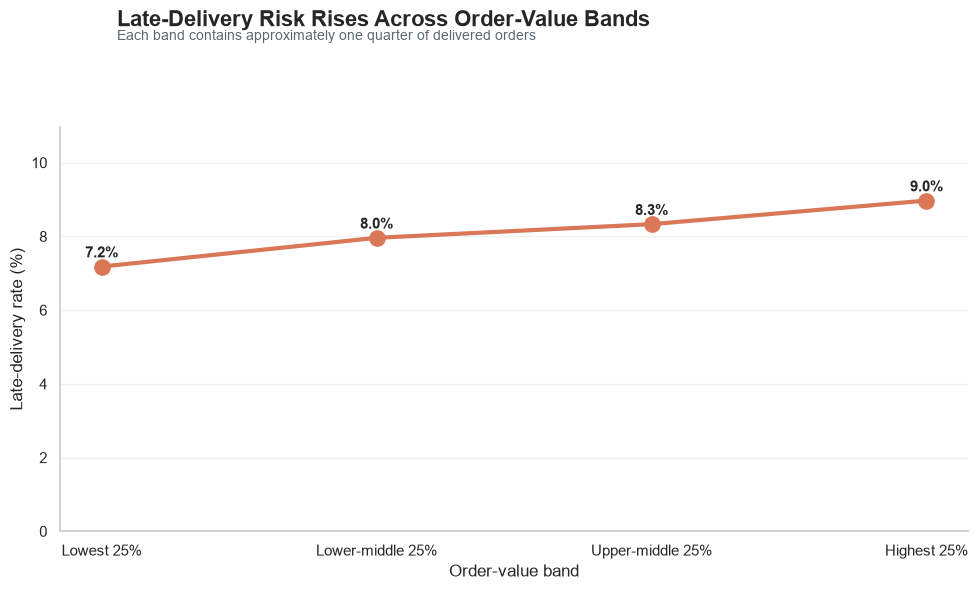

Saved figure to: ..\docs\figures\late_delivery_rate_by_order_value.png


In [ ]:
plot_data = order_value_delivery_summary.copy()

x_positions = range(len(plot_data))

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    x_positions,
    plot_data["late_delivery_rate_pct"],
    color="#D97757",
    linewidth=3,
    marker="o",
    markersize=11
)

for index, row in plot_data.iterrows():
    ax.text(
        index,
        row["late_delivery_rate_pct"] + 0.25,
        f'{row["late_delivery_rate_pct"]:.1f}%',
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

fig.suptitle(
    "Late-Delivery Risk Rises Across Order-Value Bands",
    x=0.125,
    y=0.98,
    ha="left",
    fontsize=16,
    fontweight="bold"
)

fig.text(
    0.125,
    0.93,
    "Each band contains approximately one quarter of delivered orders",
    ha="left",
    fontsize=10,
    color="#5A6772"
)

ax.set_xticks(list(x_positions))
ax.set_xticklabels(plot_data["order_value_band"])

ax.set_xlabel("Order-value band")
ax.set_ylabel("Late-delivery rate (%)")

ax.set_ylim(0, plot_data["late_delivery_rate_pct"].max() + 2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)

plt.tight_layout(rect=[0, 0, 1, 0.88])

figure_path = figures_dir / "late_delivery_rate_by_order_value.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {figure_path}")

## Product categories and delivery reliability

Product categories may be associated with delivery reliability because products
can differ in size, handling requirements, freight, seller networks, and demand.
The product table will be joined to the order-items table before categories are
linked to delivered orders.

In [ ]:
products = pd.read_csv(
    raw_data_dir / "olist_products_dataset.csv"
)

category_translation = pd.read_csv(
    raw_data_dir / "product_category_name_translation.csv"
)

print(f"Product rows: {len(products):,}")
print(f"Duplicate product IDs: {products['product_id'].duplicated().sum()}")

products_with_categories = products.merge(
    category_translation,
    on="product_category_name",
    how="left",
    validate="many_to_one"
)

products_with_categories = products_with_categories.rename(
    columns={
        "product_category_name_english": "product_category_english"
    }
)

products_with_categories["product_category_english"] = (
    products_with_categories["product_category_english"]
    .fillna("Unspecified")
)

print(
    "Products with unspecified English category:",
    (products_with_categories["product_category_english"] == "Unspecified").sum()
)

products_with_categories[
    [
        "product_id",
        "product_category_name",
        "product_category_english",
        "product_weight_g"
    ]
].head()

Product rows: 32,951
Duplicate product IDs: 0
Products with unspecified English category: 623


,product_id,product_category_name,product_category_english,product_weight_g
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery,225.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art,1000.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure,154.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby,371.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares,625.0


In [ ]:
items_with_categories = order_items.merge(
    products_with_categories[
        [
            "product_id",
            "product_category_english",
            "product_weight_g"
        ]
    ],
    on="product_id",
    how="left",
    validate="many_to_one"
)

items_with_categories["product_category_english"] = (
    items_with_categories["product_category_english"]
    .fillna("Unspecified")
)

print(f"Rows after product-category join: {len(items_with_categories):,}")
print(
    "Order items with unspecified category:",
    (items_with_categories["product_category_english"] == "Unspecified").sum()
)

items_with_categories[
    [
        "order_id",
        "product_id",
        "seller_id",
        "product_category_english",
        "product_weight_g",
        "price",
        "freight_value"
    ]
].head()

Rows after product-category join: 112,650
Order items with unspecified category: 1627


,order_id,product_id,seller_id,product_category_english,product_weight_g,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,cool_stuff,650.0,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,pet_shop,30000.0,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,furniture_decor,3050.0,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,perfumery,200.0,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,garden_tools,3750.0,199.90,18.14


In [ ]:
delivery_category_records = delivery_orders.merge(
    items_with_categories[
        [
            "order_id",
            "product_category_english",
            "product_weight_g"
        ]
    ],
    on="order_id",
    how="left",
    validate="one_to_many"
)

delivery_category_orders = (
    delivery_category_records
    .drop_duplicates(
        subset=["order_id", "product_category_english"]
    )
    .copy()
)

print(f"Delivered order-item category rows: {len(delivery_category_records):,}")
print(f"Order-category combinations: {len(delivery_category_orders):,}")
print(
    "Orders with no category record:",
    delivery_category_orders["product_category_english"].isna().sum()
)

delivery_category_orders[
    [
        "order_id",
        "late_delivery",
        "customer_state",
        "product_category_english",
        "product_weight_g"
    ]
].head()

Delivered order-item category rows: 110,189
Order-category combinations: 97,268
Orders with no category record: 0


,order_id,late_delivery,customer_state,product_category_english,product_weight_g
0,e481f51cbdc54678b7cc49136f2d6af7,False,SP,housewares,500.0
1,53cdb2fc8bc7dce0b6741e2150273451,False,BA,perfumery,400.0
2,47770eb9100c2d0c44946d9cf07ec65d,False,GO,auto,420.0
3,949d5b44dbf5de918fe9c16f97b45f8a,False,RN,pet_shop,450.0
4,ad21c59c0840e6cb83a9ceb5573f8159,False,SP,stationery,250.0


## Delivery reliability by product category

Some orders contain more than one product category. Therefore, this section uses
unique order-category combinations rather than treating each item row as an
independent delivery. Categories with fewer than 500 order-category combinations
are excluded from the comparison to reduce unstable percentage estimates.

In [ ]:
category_delivery_summary = (
    delivery_category_orders
    .groupby("product_category_english")
    .agg(
        order_category_count=("order_id", "size"),
        late_delivery_count=("late_delivery", "sum"),
        late_delivery_rate=("late_delivery", "mean"),
        median_product_weight_g=("product_weight_g", "median")
    )
    .reset_index()
)

category_delivery_summary["late_delivery_rate_pct"] = (
    category_delivery_summary["late_delivery_rate"] * 100
).round(2)

category_delivery_summary["median_product_weight_g"] = (
    category_delivery_summary["median_product_weight_g"].round(0)
)

minimum_category_order_count = 500

category_delivery_comparison = (
    category_delivery_summary
    .loc[
        category_delivery_summary["order_category_count"]
        >= minimum_category_order_count
    ]
    .sort_values(
        ["late_delivery_rate_pct", "order_category_count"],
        ascending=[False, False]
    )
)

category_delivery_comparison.head(10)

,product_category_english,order_category_count,late_delivery_count,late_delivery_rate,median_product_weight_g,late_delivery_rate_pct
27,electronics,2517,247,0.098133,200.0,9.81
7,baby,2809,258,0.091848,700.0,9.18
58,office_furniture,1254,115,0.091707,10850.0,9.17
18,construction_tools_construction,736,67,0.091033,1200.0,9.10
0,Unspecified,1412,128,0.090652,450.0,9.07
44,health_beauty,8647,775,0.089626,427.0,8.96
57,musical_instruments,611,54,0.088380,850.0,8.84
8,bed_bath_table,9272,811,0.087468,1350.0,8.75
6,auto,3809,328,0.086112,900.0,8.61
69,telephony,4093,349,0.085268,217.0,8.53


### Interpretation

Electronics had the highest observed late-delivery rate among named categories
with at least 500 order-category combinations (9.81%). Office furniture had a
similarly high late-delivery rate and a substantially higher median product
weight. Product category and weight may be associated with delivery performance,
but this analysis does not establish a causal relationship.

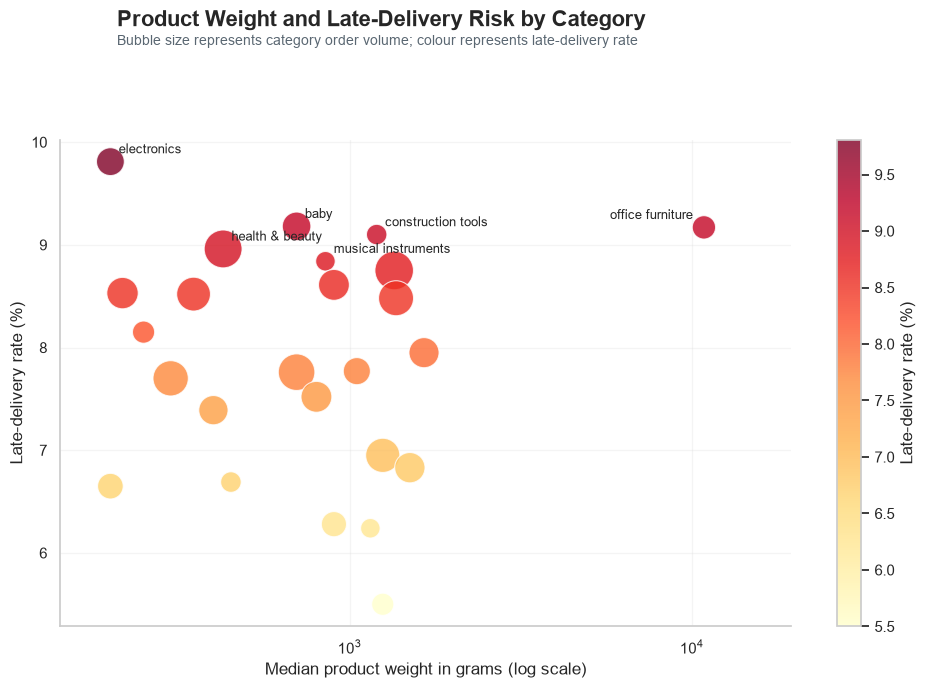

Saved figure to: ..\docs\figures\category_weight_and_delivery_risk.png


In [ ]:
plot_data = (
    category_delivery_comparison
    .loc[
        category_delivery_comparison["product_category_english"]
        != "Unspecified"
    ]
    .copy()
)

label_map = {
    "construction_tools_construction": "construction tools",
    "office_furniture": "office furniture",
    "health_beauty": "health & beauty",
    "musical_instruments": "musical instruments"
}

fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    plot_data["median_product_weight_g"],
    plot_data["late_delivery_rate_pct"],
    s=np.sqrt(plot_data["order_category_count"]) * 8,
    c=plot_data["late_delivery_rate_pct"],
    cmap="YlOrRd",
    alpha=0.8,
    edgecolor="white",
    linewidth=0.8
)

top_risk_categories = plot_data.head(6)

for _, row in top_risk_categories.iterrows():
    category_name = row["product_category_english"]

    category_label = label_map.get(
        category_name,
        category_name.replace("_", " ")
    )

    if row["median_product_weight_g"] > 5_000:
        text_offset = (-8, 6)
        horizontal_alignment = "right"
    else:
        text_offset = (6, 6)
        horizontal_alignment = "left"

    ax.annotate(
        category_label,
        (
            row["median_product_weight_g"],
            row["late_delivery_rate_pct"]
        ),
        xytext=text_offset,
        textcoords="offset points",
        fontsize=9,
        ha=horizontal_alignment
    )

fig.suptitle(
    "Product Weight and Late-Delivery Risk by Category",
    x=0.125,
    y=0.98,
    ha="left",
    fontsize=16,
    fontweight="bold"
)

fig.text(
    0.125,
    0.93,
    "Bubble size represents category order volume; colour represents late-delivery rate",
    ha="left",
    fontsize=10,
    color="#5A6772"
)

ax.set_xscale("log")

ax.set_xlabel("Median product weight in grams (log scale)")
ax.set_ylabel("Late-delivery rate (%)")

ax.set_xlim(
    plot_data["median_product_weight_g"].min() / 1.4,
    plot_data["median_product_weight_g"].max() * 1.8
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(alpha=0.2)

colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label("Late-delivery rate (%)")

plt.tight_layout(rect=[0, 0, 1, 0.88])

figure_path = figures_dir / "category_weight_and_delivery_risk.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {figure_path}")

## Delivery reliability over time

This analysis groups delivered orders by purchase month to examine whether the
late-delivery rate changed across the historical period. Purchase month is used
rather than delivery month because it reflects when the customer placed the
order.

In [32]:
delivery_orders["purchase_month"] = (
    delivery_orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

monthly_delivery_summary = (
    delivery_orders
    .groupby("purchase_month")
    .agg(
        order_count=("order_id", "size"),
        late_delivery_count=("late_delivery", "sum"),
        late_delivery_rate=("late_delivery", "mean"),
        median_delivery_days=("delivery_days", "median")
    )
    .reset_index()
)

monthly_delivery_summary["late_delivery_rate_pct"] = (
    monthly_delivery_summary["late_delivery_rate"] * 100
).round(2)

monthly_delivery_summary["median_delivery_days"] = (
    monthly_delivery_summary["median_delivery_days"].round(2)
)

monthly_delivery_summary

,purchase_month,order_count,late_delivery_count,late_delivery_rate,median_delivery_days,late_delivery_rate_pct
0,2016-09,1,1,1.000000,54.81,100.00
1,2016-10,265,3,0.011321,17.94,1.13
2,2016-12,1,0,0.000000,4.69,0.00
3,2017-01,750,23,0.030667,10.73,3.07
4,2017-02,1653,53,0.032063,10.97,3.21
5,2017-03,2546,142,0.055774,10.13,5.58
6,2017-04,2303,181,0.078593,12.75,7.86
7,2017-05,3545,128,0.036107,9.79,3.61
8,2017-06,3135,121,0.038596,10.80,3.86
9,2017-07,3872,133,0.034349,10.16,3.43


## Late-delivery rate over time

Months with fewer than 1,000 delivered orders are excluded from the chart because
their late-delivery percentages are too unstable for reliable comparison.

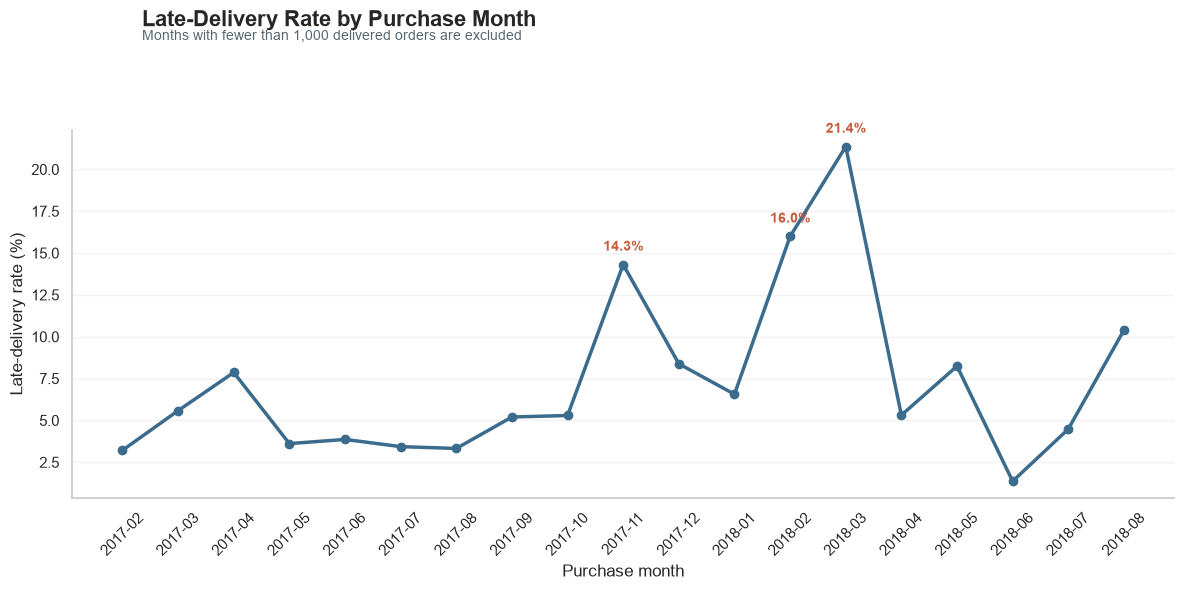

Saved figure to: ..\docs\figures\late_delivery_rate_over_time.png


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

figures_dir = Path("../docs/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

monthly_plot_data = (
    monthly_delivery_summary
    .loc[
        monthly_delivery_summary["order_count"] >= 1_000
    ]
    .copy()
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    monthly_plot_data["purchase_month"],
    monthly_plot_data["late_delivery_rate_pct"],
    color="#3B6C8E",
    linewidth=2.5,
    marker="o",
    markersize=6
)

peak_months = monthly_plot_data.nlargest(
    3,
    "late_delivery_rate_pct"
)

for _, row in peak_months.iterrows():
    ax.annotate(
        f'{row["late_delivery_rate_pct"]:.1f}%',
        (row["purchase_month"], row["late_delivery_rate_pct"]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        fontweight="bold",
        color="#C75C3C"
    )

fig.suptitle(
    "Late-Delivery Rate by Purchase Month",
    x=0.125,
    y=0.98,
    ha="left",
    fontsize=16,
    fontweight="bold"
)

fig.text(
    0.125,
    0.93,
    "Months with fewer than 1,000 delivered orders are excluded",
    ha="left",
    fontsize=10,
    color="#5A6772"
)

ax.set_xlabel("Purchase month")
ax.set_ylabel("Late-delivery rate (%)")

ax.tick_params(axis="x", rotation=45)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)

plt.tight_layout(rect=[0, 0, 1, 0.88])

figure_path = figures_dir / "late_delivery_rate_over_time.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {figure_path}")

### Interpretation

Late-delivery rates varied substantially over time. Rates increased in November
2017 and reached their highest observed level in March 2018 (21.4%), before
falling sharply in April 2018. These patterns may reflect operational,
seasonal, or marketplace factors, but the dataset alone cannot identify their
cause.

In [36]:
import duckdb

con = duckdb.connect()

con.register(
    "delivery_orders",
    delivery_orders
)

monthly_sql_summary = con.execute(
    """
    WITH monthly_source AS (
        SELECT
            strftime(
                order_purchase_timestamp,
                '%Y-%m'
            ) AS purchase_month,

            late_delivery,

            delivery_days

        FROM delivery_orders
    )

    SELECT
        purchase_month,

        COUNT(*) AS order_count,

        SUM(
            CASE
                WHEN late_delivery THEN 1
                ELSE 0
            END
        ) AS late_delivery_count,

        ROUND(
            100.0 * AVG(
                CASE
                    WHEN late_delivery THEN 1.0
                    ELSE 0.0
                END
            ),
            2
        ) AS late_delivery_rate_pct,

        ROUND(
            MEDIAN(delivery_days),
            2
        ) AS median_delivery_days

    FROM monthly_source

    GROUP BY purchase_month

    HAVING COUNT(*) >= 1000

    ORDER BY purchase_month
    """
).df()

monthly_sql_summary

,purchase_month,order_count,late_delivery_count,late_delivery_rate_pct,median_delivery_days
0,2017-02,1653,53.0,3.21,10.97
1,2017-03,2546,142.0,5.58,10.13
2,2017-04,2303,181.0,7.86,12.75
3,2017-05,3545,128.0,3.61,9.79
4,2017-06,3135,121.0,3.86,10.80
5,2017-07,3872,133.0,3.43,10.16
6,2017-08,4193,139.0,3.32,9.77
7,2017-09,4150,216.0,5.20,10.31
8,2017-10,4478,237.0,5.29,10.26
9,2017-11,7288,1043.0,14.31,12.70


## SQL state ranking with a window function

A window function assigns a rank to each state after its delivery metrics have
been calculated. States with at least 1,000 delivered orders are included.

In [37]:
state_sql_summary = con.execute(
    """
    WITH state_metrics AS (
        SELECT
            customer_state,

            COUNT(*) AS delivered_order_count,

            SUM(
                CASE
                    WHEN late_delivery THEN 1
                    ELSE 0
                END
            ) AS late_delivery_count,

            ROUND(
                100.0 * AVG(
                    CASE
                        WHEN late_delivery THEN 1.0
                        ELSE 0.0
                    END
                ),
                2
            ) AS late_delivery_rate_pct,

            ROUND(
                MEDIAN(delivery_days),
                2
            ) AS median_delivery_days

        FROM delivery_orders

        GROUP BY customer_state

        HAVING COUNT(*) >= 1000
    )

    SELECT
        customer_state,
        delivered_order_count,
        late_delivery_count,
        late_delivery_rate_pct,
        median_delivery_days,

        DENSE_RANK() OVER (
            ORDER BY late_delivery_rate_pct DESC
        ) AS late_delivery_risk_rank

    FROM state_metrics

    ORDER BY late_delivery_risk_rank
    """
).df()

state_sql_summary

,customer_state,delivered_order_count,late_delivery_count,late_delivery_rate_pct,median_delivery_days,late_delivery_risk_rank
0,CE,1279,196.0,15.32,18.21,1
1,BA,3256,457.0,14.04,16.91,2
2,RJ,12350,1664.0,13.47,12.04,3
3,ES,1995,244.0,12.23,13.64,4
4,PE,1593,172.0,10.80,15.70,5
5,SC,3546,346.0,9.76,13.01,6
6,GO,1957,160.0,8.18,13.95,7
7,RS,5344,382.0,7.15,13.18,8
8,DF,2080,147.0,7.07,11.36,9
9,SP,40494,2387.0,5.89,7.21,10


## Processed analysis tables

The following tables are created by this notebook from the raw Olist files.
They are saved in the processed-data folder so that the SQL queries can be
reproduced without manually rebuilding every intermediate table.

In [39]:
processed_data_dir = Path("../data/processed")
processed_data_dir.mkdir(parents=True, exist_ok=True)

delivery_orders_export = delivery_orders.copy()

delivery_orders_export["seller_complexity"] = np.where(
    delivery_orders_export["unique_sellers"] > 1,
    "Multiple sellers",
    "Single seller"
)

delivery_orders_export["order_value_band"] = pd.qcut(
    delivery_orders_export["total_order_value"],
    q=4,
    labels=[
        "Lowest 25%",
        "Lower-middle 25%",
        "Upper-middle 25%",
        "Highest 25%"
    ]
)

delivery_orders_export["purchase_month"] = (
    delivery_orders_export["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

delivery_orders_export = delivery_orders_export[
    [
        "order_id",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "customer_state",
        "late_delivery",
        "delivery_days",
        "delivery_gap_days",
        "item_count",
        "unique_sellers",
        "total_order_value",
        "seller_complexity",
        "order_value_band",
        "purchase_month"
    ]
].copy()

delivery_orders_export_path = (
    processed_data_dir / "delivery_orders_analysis.csv"
)

delivery_orders_export.to_csv(
    delivery_orders_export_path,
    index=False
)

delivery_categories_export = delivery_category_orders[
    [
        "order_id",
        "product_category_english",
        "product_weight_g",
        "late_delivery",
        "customer_state"
    ]
].copy()

delivery_categories_export_path = (
    processed_data_dir / "delivery_order_categories.csv"
)

delivery_categories_export.to_csv(
    delivery_categories_export_path,
    index=False
)

print(f"Saved: {delivery_orders_export_path}")
print(f"Saved: {delivery_categories_export_path}")
print(f"Order-level rows: {len(delivery_orders_export):,}")
print(f"Order-category rows: {len(delivery_categories_export):,}")

NameError: name 'delivery_category_orders' is not defined

In [40]:
print(
    "Order-level export exists:",
    delivery_orders_export_path.exists()
)

print(
    "Saved file:",
    delivery_orders_export_path
)

print(
    "Rows saved:",
    len(delivery_orders_export)
)

Order-level export exists: True
Saved file: ..\data\processed\delivery_orders_analysis.csv
Rows saved: 96470


In [41]:
sql_queries = """
-- E-commerce Delivery Reliability Analysis
-- These queries use the processed table created by
-- notebooks/01_data_inventory.ipynb.

-- 1. Overall delivery reliability baseline

WITH delivery_orders AS (
    SELECT *
    FROM read_csv_auto(
        'data/processed/delivery_orders_analysis.csv'
    )
)

SELECT
    COUNT(*) AS delivered_order_count,

    SUM(
        CASE
            WHEN late_delivery THEN 1
            ELSE 0
        END
    ) AS late_delivery_count,

    ROUND(
        100.0 * AVG(
            CASE
                WHEN late_delivery THEN 1.0
                ELSE 0.0
            END
        ),
        2
    ) AS late_delivery_rate_pct,

    ROUND(
        MEDIAN(delivery_days),
        2
    ) AS median_delivery_days

FROM delivery_orders;


-- 2. Monthly delivery reliability
-- Months with fewer than 1,000 orders are excluded.

WITH delivery_orders AS (
    SELECT *
    FROM read_csv_auto(
        'data/processed/delivery_orders_analysis.csv'
    )
)

SELECT
    purchase_month,

    COUNT(*) AS order_count,

    SUM(
        CASE
            WHEN late_delivery THEN 1
            ELSE 0
        END
    ) AS late_delivery_count,

    ROUND(
        100.0 * AVG(
            CASE
                WHEN late_delivery THEN 1.0
                ELSE 0.0
            END
        ),
        2
    ) AS late_delivery_rate_pct,

    ROUND(
        MEDIAN(delivery_days),
        2
    ) AS median_delivery_days

FROM delivery_orders

GROUP BY purchase_month

HAVING COUNT(*) >= 1000

ORDER BY purchase_month;


-- 3. State ranking using a window function

WITH delivery_orders AS (
    SELECT *
    FROM read_csv_auto(
        'data/processed/delivery_orders_analysis.csv'
    )
),

state_metrics AS (
    SELECT
        customer_state,

        COUNT(*) AS delivered_order_count,

        SUM(
            CASE
                WHEN late_delivery THEN 1
                ELSE 0
            END
        ) AS late_delivery_count,

        ROUND(
            100.0 * AVG(
                CASE
                    WHEN late_delivery THEN 1.0
                    ELSE 0.0
                END
            ),
            2
        ) AS late_delivery_rate_pct,

        ROUND(
            MEDIAN(delivery_days),
            2
        ) AS median_delivery_days

    FROM delivery_orders

    GROUP BY customer_state

    HAVING COUNT(*) >= 1000
)

SELECT
    customer_state,
    delivered_order_count,
    late_delivery_count,
    late_delivery_rate_pct,
    median_delivery_days,

    DENSE_RANK() OVER (
        ORDER BY late_delivery_rate_pct DESC
    ) AS late_delivery_risk_rank

FROM state_metrics

ORDER BY late_delivery_risk_rank;
"""

sql_file_path = Path("../sql/analysis_queries.sql")

sql_file_path.write_text(
    sql_queries,
    encoding="utf-8"
)

print(f"Saved SQL queries to: {sql_file_path}")
print(f"File exists: {sql_file_path.exists()}")

Saved SQL queries to: ..\sql\analysis_queries.sql
File exists: True
